**Dataset:** Bee Colony Census Data by County

This dataset contains information on bee colony census data collected across various counties in the United States. It provides details such as the year of observation, agricultural district, county, and the number of bee colonies or related metrics (Value).

**Link:**https://www.kaggle.com/datasets/thedevastator/bee-colony-census-and-loss-data/data

**Features of the Dataset**

index: Row index, not essential for analysis.

Year: Year of observation (e.g., 2012, 2013).

Period: Period of observation (e.g., "END OF DEC").

State: The state where the data was collected (e.g., "ALABAMA").

State ANSI: A numeric code representing the state.

Ag District: The agricultural district within the state.

Ag District Code: A numeric code representing the agricultural district.

County: The county where the data was collected.

County ANSI: A numeric code representing the county (some missing values).

Value: The observed metric (e.g., number of bee colonies). It appears to be a mix of numbers and strings, requiring cleanup for analysis.

CV (%): Coefficient of variation, representing the reliability of the Value (many missing values).
Key Observations.

Value: This is the primary variable of interest. It likely represents the count or metric related to bee colonies.

County ANSI: Contains some missing values.
CV (%): Indicates reliability but has significant missing data

In [60]:
# Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

**Step 1: Problem Understanding**

Objective: Define tasks and understand the dataset.


**Dataset Selection:**

This dataset contains information about bee colony values across counties, states, and agricultural districts, including time-period observations.
Key features: Year, State, Ag District, County, and Value.
Task Definition:

**Classification Task:**

Predict whether the bee colony Value is above or below the median for a given Year or State.
Prediction Task: Predict the exact Value of bee colonies using features like Year, State, and Ag District.

In [61]:
# Load the dataset
file_path = '/content/Bee Colony Census Data by County.csv'
data = pd.read_csv(file_path)

In [62]:
# Convert it to a pandas dataframe
column_names = data.columns
df = pd.DataFrame(data, columns=column_names)# Add the target variable to the DataFrame

In [63]:
# Show the first few rows of the DataFrame
df.head()

,index,Year,Period,State,State ANSI,Ag District,Ag District Code,County,County ANSI,Value,CV (%)
0,0,2012,END OF DEC,ALABAMA,1,BLACK BELT,40,AUTAUGA,1.0,119,27.7
1,1,2012,END OF DEC,ALABAMA,1,BLACK BELT,40,DALLAS,47.0,65,27.7
2,2,2012,END OF DEC,ALABAMA,1,BLACK BELT,40,ELMORE,51.0,190,27.7
3,3,2012,END OF DEC,ALABAMA,1,BLACK BELT,40,GREENE,63.0,14,27.7
4,4,2012,END OF DEC,ALABAMA,1,BLACK BELT,40,HALE,65.0,10,27.7


In [64]:
# Show feature types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7830 entries, 0 to 7829
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   index             7830 non-null   int64  
 1   Year              7830 non-null   int64  
 2   Period            7830 non-null   object 
 3   State             7830 non-null   object 
 4   State ANSI        7830 non-null   int64  
 5   Ag District       7830 non-null   object 
 6   Ag District Code  7830 non-null   int64  
 7   County            7830 non-null   object 
 8   County ANSI       7821 non-null   float64
 9   Value             7830 non-null   object 
 10  CV (%)            2761 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 673.0+ KB


**Step 2: Data Preparation**

**Objective:** Clean and prepare the data for analysis and modeling.

**Handling Missing Data:**
County ANSI and CV (%) have missing values that need to be dropped or imputed.

**Creating Features:**
Encode categorical variables (State, Ag District, Period) using LabelEncoder.

**Scaling/Normalization:**
Apply StandardScaler to numerical features (Year, State ANSI, Ag District Code) for consistent scaling.

In [65]:
# Step 1: Handle missing data
# Convert 'Value' column to numeric and drop rows with invalid values
data['Value'] = pd.to_numeric(data['Value'], errors='coerce')
data_cleaned = data.dropna(subset=['Value'])

In [66]:
# Step 2: Encode categorical variables safely
categorical_columns = ['State', 'Ag District', 'Period']
label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    data_cleaned.loc[:, col] = le.fit_transform(data_cleaned[col])  # Use .loc to avoid SettingWithCopyWarning
    label_encoders[col] = le  # Store encoders for future use

In [70]:
# Ensure `Value` is numeric
data_cleaned['Value'] = pd.to_numeric(data_cleaned['Value'], errors='coerce')

# Drop rows with missing `Value`
data_cleaned = data_cleaned.dropna(subset=['Value'])

# Create `Above_Median` safely
median_value = data_cleaned['Value'].median()
data_cleaned.loc[:, 'Above_Median'] = (data_cleaned['Value'] > median_value).astype(int)

# Convert numerical columns to float before scaling
numerical_columns = ['Year', 'State ANSI', 'Ag District Code']
data_cleaned.loc[:, numerical_columns] = data_cleaned[numerical_columns].astype(float)

# Apply StandardScaler for normalization
scaler = StandardScaler()
data_cleaned.loc[:, numerical_columns] = scaler.fit_transform(data_cleaned[numerical_columns])

In [71]:
# Step 4: Split the data into training and test sets
from sklearn.model_selection import train_test_split

# Classification data split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_classification, test_size=0.2, random_state=42)

# Regression data split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_regression, test_size=0.2, random_state=42)

# Display a preview of the cleaned and prepared data
print("Preview of the Cleaned Dataset:")
print(data_cleaned.head())

Preview of the Cleaned Dataset:
   index      Year Period State  State ANSI Ag District  Ag District Code  \
0      0  1.093597      0     0   -2.032102           1         -0.307552   
1      1  1.093597      0     0   -2.032102           1         -0.307552   
2      2  1.093597      0     0   -2.032102           1         -0.307552   
3      3  1.093597      0     0   -2.032102           1         -0.307552   
4      4  1.093597      0     0   -2.032102           1         -0.307552   

    County  County ANSI  Value CV (%)  Above_Median  
0  AUTAUGA          1.0  119.0   27.7             1  
1   DALLAS         47.0   65.0   27.7             0  
2   ELMORE         51.0  190.0   27.7             1  
3   GREENE         63.0   14.0   27.7             0  
4     HALE         65.0   10.0   27.7             0  


**Step 3: Exploratory Data Analysis (EDA)**

**Objective:** Understand data trends, distributions, and relationships.


**Trend Analysis:**
Line plots to visualize how Value changes across years.

**Scatter Plots & Box Plots:**
Examine relationships between Value and features like Year or State.

**Correlation Analysis:**
Use a heatmap to identify relationships between numerical features and the target variable Value.

**Hypothesis Testing:**
Test whether features like Ag District Code or State ANSI significantly affect Value.


In [72]:
# Step 3. EXPLORATORY DATA ANALYSIS

#3.1 Analyzing basic trend statistics, generating box plots, scatter plots, among others.

#3.1.1. Trend statistics
df.describe()

,index,Year,State ANSI,Ag District Code,County ANSI
count,7830.000000,7830.000000,7830.000000,7830.000000,7821.000000
mean,3914.500000,2007.212005,30.292976,48.379949,92.702084
std,2260.470637,4.065470,15.004933,25.675393,84.042373
min,0.000000,2002.000000,1.000000,10.000000,1.000000
25%,1957.250000,2002.000000,19.000000,30.000000,33.000000
50%,3914.500000,2007.000000,29.000000,50.000000,75.000000
75%,5871.750000,2012.000000,45.000000,70.000000,127.000000
max,7829.000000,2012.000000,56.000000,97.000000,810.000000


In [73]:
# 1. Summary Statistics
summary_stats = data_cleaned.describe()

# Display summary statistics using Pandas' built-in print function
print("Summary Statistics:")
print(summary_stats)

# Optionally, save summary statistics to a CSV file for further review
summary_stats.to_csv("summary_statistics.csv", index=True)
print("Summary statistics saved to 'summary_statistics.csv'")


Summary Statistics:
             index          Year    State ANSI  Ag District Code  County ANSI  \
count  4776.000000  4.776000e+03  4.776000e+03      4.776000e+03  4771.000000   
mean   3756.701843 -4.760755e-17 -2.380378e-17     -2.231604e-17    94.801509   
std    2248.447404  1.000105e+00  1.000105e+00      1.000105e+00    83.235458   
min       0.000000 -1.392963e+00 -2.032102e+00     -1.509869e+00     1.000000   
25%    1840.750000 -1.392963e+00 -8.218033e-01     -7.083247e-01    35.000000   
50%    3660.500000 -1.496830e-01 -1.494149e-01      9.321983e-02    79.000000   
75%    5606.250000  1.093597e+00  9.264064e-01      8.947643e-01   133.000000   
max    7819.000000  1.093597e+00  1.666034e+00      1.976849e+00   810.000000   

             Value  Above_Median  
count  4776.000000   4776.000000  
mean    152.965662      0.498325  
std     193.324729      0.500050  
min       3.000000      0.000000  
25%      27.750000      0.000000  
50%      74.000000      0.000000  
75%  

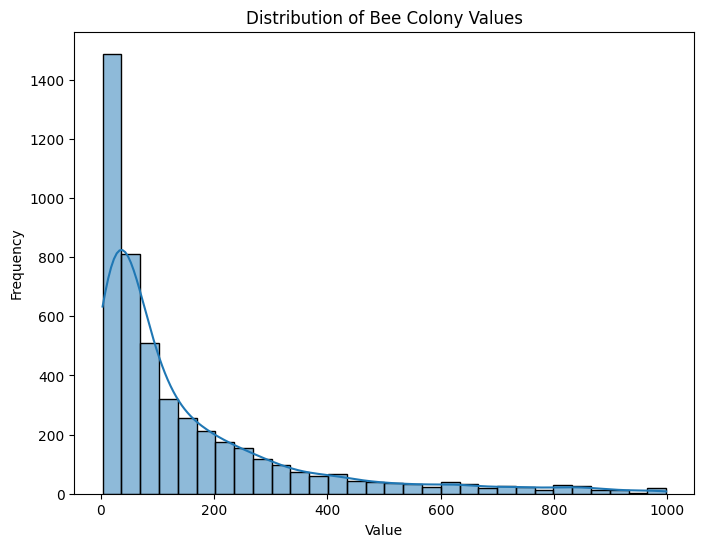

In [74]:
# 2. Distribution of the Target Variable ('Value')
plt.figure(figsize=(8, 6))
sns.histplot(data_cleaned['Value'], bins=30, kde=True)
plt.title("Distribution of Bee Colony Values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

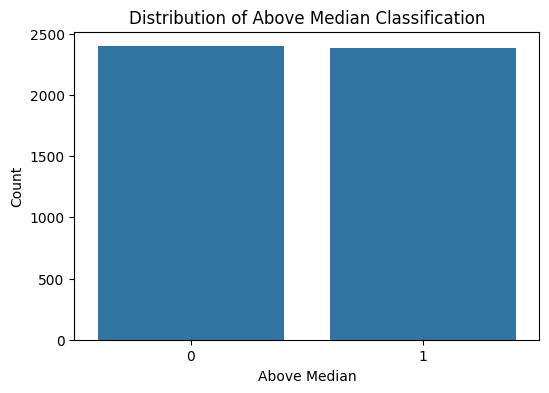

In [75]:
# 3. Target Variable ('Above_Median') Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Above_Median', data=data_cleaned)
plt.title("Distribution of Above Median Classification")
plt.xlabel("Above Median")
plt.ylabel("Count")
plt.show()

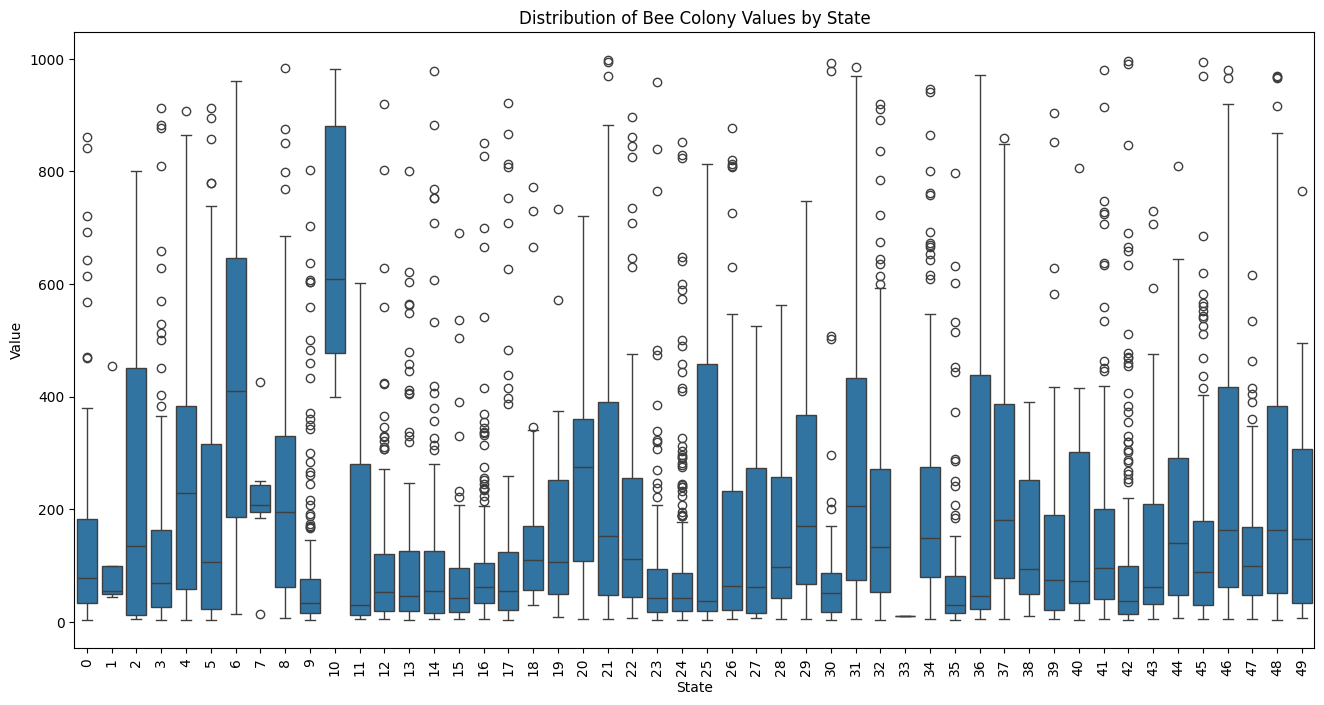

In [76]:
# 6. Boxplot for Value by State
plt.figure(figsize=(16, 8))
sns.boxplot(x='State', y='Value', data=data_cleaned)
plt.xticks(rotation=90)
plt.title("Distribution of Bee Colony Values by State")
plt.xlabel("State")
plt.ylabel("Value")
plt.show()


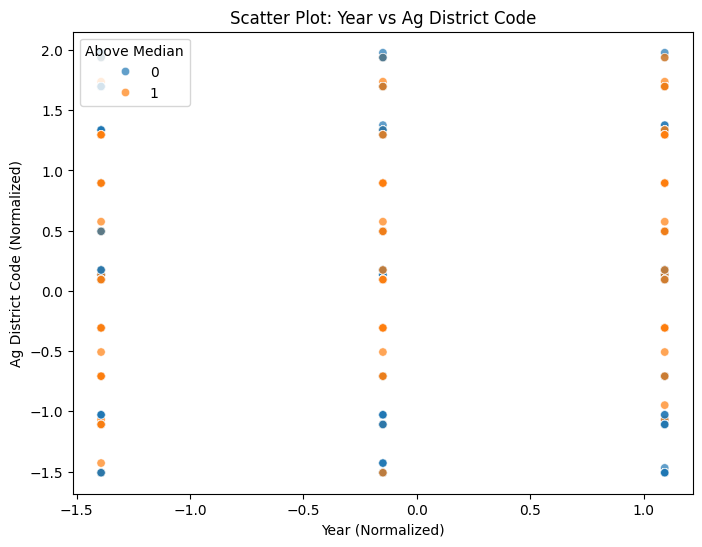

In [77]:
# 1. Scatter Plot: Relationship between two predictors
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Year', y='Ag District Code', data=data_cleaned, hue='Above_Median', alpha=0.7)
plt.title("Scatter Plot: Year vs Ag District Code")
plt.xlabel("Year (Normalized)")
plt.ylabel("Ag District Code (Normalized)")
plt.legend(title="Above Median")
plt.show()

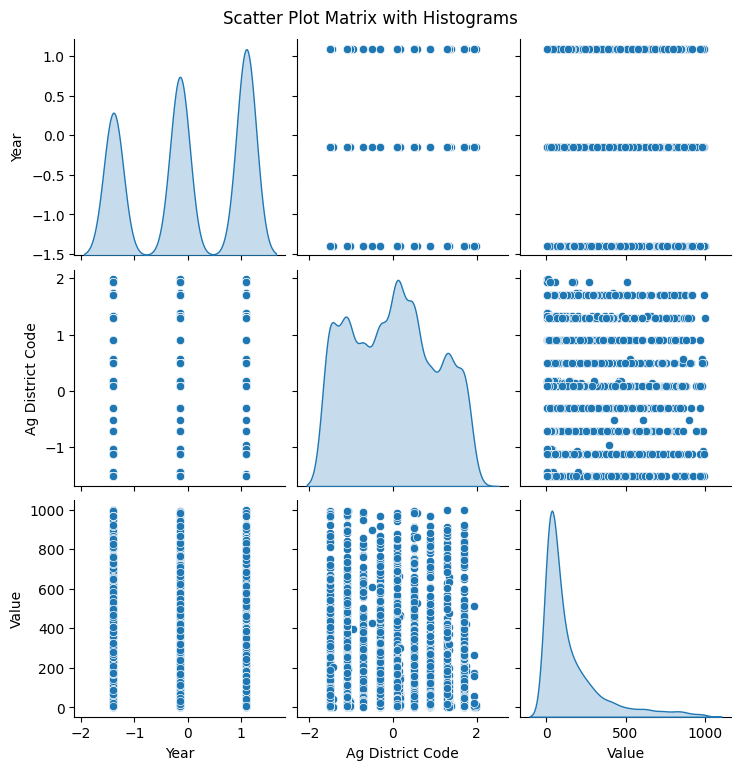

In [78]:
# 2. Scatter Plot Matrix with Histograms
predictors = ['Year', 'Ag District Code', 'Value']
sns.pairplot(data_cleaned[predictors], diag_kind='kde', kind='scatter', height=2.5)
plt.suptitle("Scatter Plot Matrix with Histograms", y=1.02)
plt.show()

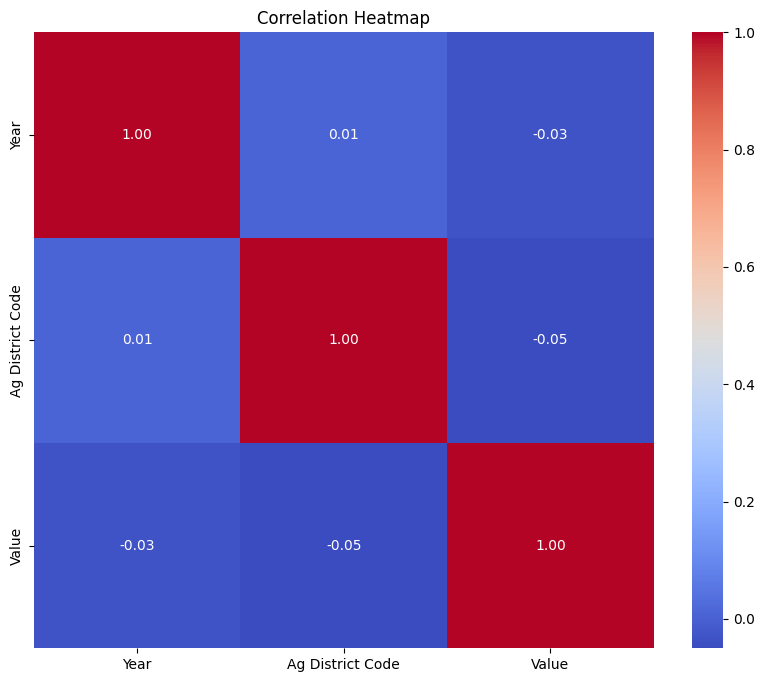

In [79]:
# 3. Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = data_cleaned[predictors].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [80]:
# 4. Multicollinearity Analysis: Variance Inflation Factor (VIF)
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Add a constant to the dataset for VIF computation
X_with_constant = add_constant(data_cleaned[predictors].drop(columns=['Value'], errors='ignore'))
vif_data = pd.DataFrame({
    "Feature": X_with_constant.columns,
    "VIF": [variance_inflation_factor(X_with_constant.values, i) for i in range(X_with_constant.shape[1])]
})

# Display VIF results using Pandas
print("Multicollinearity Analysis (VIF):")
print(vif_data)

# Optionally, save the VIF data to a CSV file for inspection
vif_data.to_csv("vif_analysis.csv", index=False)
print("VIF results saved to 'vif_analysis.csv'")


Multicollinearity Analysis (VIF):
            Feature       VIF
0             const  1.000000
1              Year  1.000109
2  Ag District Code  1.000109
VIF results saved to 'vif_analysis.csv'


**Step 4: Setup Phase**

**Objective:** Define features and target variables, and split data for training/testing.

**Define Features (X):**
Example features: Year, State, Ag District, Period, Ag District Code.

**Define Target (y):**
Regression: Value.
Classification: Above_Median (binary target derived from Value).

**Split Data:**
Use train_test_split to divide the dataset into training (80%) and testing (20%).

In [81]:
# Define the predictors and target variables
features = ['Year', 'State', 'Ag District', 'Period', 'Ag District Code']
target_classification = 'Above_Median'  # Classification target
target_regression = 'Value'  # Regression target

In [82]:
# Separate features (X) and target variables (y)
X = data_cleaned[features]
y_classification = data_cleaned[target_classification]  # Binary classification target
y_regression = data_cleaned[target_regression]  # Regression target

In [83]:
# Split the data into training and testing sets
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_classification, test_size=0.2, random_state=42)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_regression, test_size=0.2, random_state=42)

# Output a preview of the training data for verification
print("Preview of Training Data for Classification:")
print(X_train_clf.head())
print("Classification Target Preview:")
print(y_train_clf.head())

print("\nPreview of Training Data for Regression:")
print(X_train_reg.head())
print("Regression Target Preview:")
print(y_train_reg.head())

Preview of Training Data for Classification:
          Year State Ag District Period  Ag District Code
3131 -0.149683     9          35      0         -0.708325
4002 -0.149683    23          64      0          0.894764
5900 -1.392963    12          64      0          1.295537
168   1.093597     4          38      0         -1.509869
7314 -1.392963    41          12      0          0.093220
Classification Target Preview:
3131    1
4002    0
5900    1
168     1
7314    0
Name: Above_Median, dtype: int64

Preview of Training Data for Regression:
          Year State Ag District Period  Ag District Code
3131 -0.149683     9          35      0         -0.708325
4002 -0.149683    23          64      0          0.894764
5900 -1.392963    12          64      0          1.295537
168   1.093597     4          38      0         -1.509869
7314 -1.392963    41          12      0          0.093220
Regression Target Preview:
3131    174.0
4002     29.0
5900    157.0
168     213.0
7314      7.0
Name: 

**Step 5: Modeling Phase**

Objective: Train several machine learning models.

**Classification Models:**

Logistic Regression

Decision Tree Classifier

Random Forest Classifier

Support Vector Machine (SVM)

**Regression Models:**

Linear Regression

Polynomial Regression

Decision Tree Regressor

Random Forest Regressor

In [84]:
# Import necessary libraries for classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Initialize classification models
classification_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='linear', random_state=42)
}

classification_results = {}

# Train and evaluate each classification model
for model_name, model in classification_models.items():
    # Train the model
    model.fit(X_train_clf, y_train_clf)

    # Predict on test data
    y_pred_clf = model.predict(X_test_clf)

    # Evaluate performance
    accuracy = accuracy_score(y_test_clf, y_pred_clf)
    classification_results[model_name] = accuracy

# Display classification model results
print("Classification Model Accuracies:")
for model, accuracy in classification_results.items():
    print(f"{model}: {accuracy:.4f}")

Classification Model Accuracies:
Logistic Regression: 0.5408
Decision Tree: 0.6098
Random Forest: 0.6119
SVM: 0.5408


In [85]:
# Import necessary libraries for regression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Initialize regression models
regression_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

regression_results = {}

# Train and evaluate each regression model
for model_name, model in regression_models.items():
    # Train the model
    model.fit(X_train_reg, y_train_reg)

    # Predict on test data
    y_pred_reg = model.predict(X_test_reg)

    # Evaluate performance
    mse = mean_squared_error(y_test_reg, y_pred_reg)
    mae = mean_absolute_error(y_test_reg, y_pred_reg)
    r2 = r2_score(y_test_reg, y_pred_reg)

    # Store results
    regression_results[model_name] = {
        'MSE': mse,
        'MAE': mae,
        'R2 Score': r2
    }

# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train_reg)
X_poly_test = poly.transform(X_test_reg)
poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train_reg)
y_poly_pred = poly_model.predict(X_poly_test)

# Evaluate Polynomial Regression
regression_results['Polynomial Regression'] = {
    'MSE': mean_squared_error(y_test_reg, y_poly_pred),
    'MAE': mean_absolute_error(y_test_reg, y_poly_pred),
    'R2 Score': r2_score(y_test_reg, y_poly_pred)
}

# Display regression model results
print("\nRegression Model Results:")
for model, metrics in regression_results.items():
    print(f"{model}: MSE={metrics['MSE']:.4f}, MAE={metrics['MAE']:.4f}, R2={metrics['R2 Score']:.4f}")


Regression Model Results:
Linear Regression: MSE=34268.0917, MAE=131.8659, R2=0.0095
Decision Tree: MSE=41380.1989, MAE=135.5153, R2=-0.1961
Random Forest: MSE=38487.0316, MAE=131.5442, R2=-0.1125
Polynomial Regression: MSE=34293.1972, MAE=131.4686, R2=0.0087


**Step 6: Evaluation Phase**

**Objective:** Evaluate model performance.


**Metrics for Classification:**

Accuracy, Precision, Recall, F1 Score, and Cross-Validation Accuracy.

**Metrics for Regression:**

Mean Squared Error (MSE), Mean Absolute Error (MAE), and R² Score.

**Cross-Validation:**

Perform k-fold cross-validation for robust performance measures.

In [86]:
# step6 Import metrics for classification evaluation
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import cross_val_score

classification_evaluation = {}

# Evaluate each classification model
for model_name, model in classification_models.items():
    # Predict on test data
    y_pred_clf = model.predict(X_test_clf)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test_clf, y_pred_clf)
    precision = precision_score(y_test_clf, y_pred_clf)
    recall = recall_score(y_test_clf, y_pred_clf)
    f1 = f1_score(y_test_clf, y_pred_clf)

    # Cross-validation accuracy
    cv_accuracy = cross_val_score(model, X_train_clf, y_train_clf, cv=5, scoring='accuracy').mean()

    # Store evaluation results
    classification_evaluation[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Cross-Val Accuracy': cv_accuracy
    }

# Display classification evaluation results
import pandas as pd
classification_evaluation_df = pd.DataFrame(classification_evaluation).T
print("Classification Model Evaluation Results:")
print(classification_evaluation_df)

Classification Model Evaluation Results:
                     Accuracy  Precision    Recall  F1 Score  \
Logistic Regression  0.540795   0.559908  0.494908  0.525405   
Decision Tree        0.609833   0.641827  0.543788  0.588754   
Random Forest        0.611925   0.632159  0.584521  0.607407   
SVM                  0.540795   0.560185  0.492872  0.524377   

                     Cross-Val Accuracy  
Logistic Regression            0.544503  
Decision Tree                  0.625393  
Random Forest                  0.636126  
SVM                            0.554450  


In [87]:
# Evaluate regression models
regression_evaluation = {}

# Evaluate each regression model
for model_name, model in regression_models.items():
    # Predict on test data
    y_pred_reg = model.predict(X_test_reg)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test_reg, y_pred_reg)
    mae = mean_absolute_error(y_test_reg, y_pred_reg)
    r2 = r2_score(y_test_reg, y_pred_reg)

    # Cross-validation MSE and MAE
    cv_mse = -cross_val_score(model, X_train_reg, y_train_reg, cv=5, scoring='neg_mean_squared_error').mean()
    cv_mae = -cross_val_score(model, X_train_reg, y_train_reg, cv=5, scoring='neg_mean_absolute_error').mean()

    # Store evaluation results
    regression_evaluation[model_name] = {
        'MSE': mse,
        'MAE': mae,
        'R2 Score': r2,
        'Cross-Val MSE': cv_mse,
        'Cross-Val MAE': cv_mae
    }

# Polynomial Regression (manually computed cross-validation)
X_poly_train = poly.fit_transform(X_train_reg)
cv_poly_mse = -cross_val_score(poly_model, X_poly_train, y_train_reg, cv=5, scoring='neg_mean_squared_error').mean()
cv_poly_mae = -cross_val_score(poly_model, X_poly_train, y_train_reg, cv=5, scoring='neg_mean_absolute_error').mean()
regression_evaluation['Polynomial Regression'] = {
    'MSE': regression_results['Polynomial Regression']['MSE'],
    'MAE': regression_results['Polynomial Regression']['MAE'],
    'R2 Score': regression_results['Polynomial Regression']['R2 Score'],
    'Cross-Val MSE': cv_poly_mse,
    'Cross-Val MAE': cv_poly_mae
}

# Display regression evaluation results
regression_evaluation_df = pd.DataFrame(regression_evaluation).T
print("\nRegression Model Evaluation Results:")
print(regression_evaluation_df)


Regression Model Evaluation Results:
                                MSE         MAE  R2 Score  Cross-Val MSE  \
Linear Regression      34268.091743  131.865875  0.009460   37986.249018   
Decision Tree          41380.198917  135.515308 -0.196120   44433.867582   
Random Forest          38487.031563  131.544246 -0.112491   39899.787596   
Polynomial Regression  34293.197198  131.468562  0.008734   37668.744783   

                       Cross-Val MAE  
Linear Regression         139.314017  
Decision Tree             137.566606  
Random Forest             133.525450  
Polynomial Regression     138.497407  


**Step 7: Deployment Phase**

**Objective:** Deploy the best models for predictions and save them.

**Model Deployment:**

Save the best-performing classification and regression models using joblib.

**Predictions:**
Use the saved models to make predictions on new data.

In [88]:
# Import necessary library to save models
import joblib

# Assuming Random Forest is the best for both classification and regression
best_classification_model = classification_models['Random Forest']
best_regression_model = regression_models['Random Forest']

# Save the models to files
joblib.dump(best_classification_model, 'best_classification_model.pkl')
joblib.dump(best_regression_model, 'best_regression_model.pkl')

print("Models saved successfully:")
print("1. Classification Model: 'best_classification_model.pkl'")
print("2. Regression Model: 'best_regression_model.pkl'")


Models saved successfully:
1. Classification Model: 'best_classification_model.pkl'
2. Regression Model: 'best_regression_model.pkl'


In [89]:
# Example new data for predictions (replace with actual new data)
new_data_classification = pd.DataFrame(
    [[2022, 5, 2, 1, 3]],
    columns=['Year', 'State', 'Ag District', 'Period', 'Ag District Code']
)
new_data_regression = pd.DataFrame(
    [[2022, 5, 2, 1, 3]],
    columns=['Year', 'State', 'Ag District', 'Period', 'Ag District Code']
)

# Load models
classification_model = joblib.load('best_classification_model.pkl')
regression_model = joblib.load('best_regression_model.pkl')

# Make predictions
classification_prediction = classification_model.predict(new_data_classification)
regression_prediction = regression_model.predict(new_data_regression)

print("Predictions on New Data:")
print(f"Classification Prediction: {classification_prediction[0]} (Above Median or Not)")
print(f"Regression Prediction: {regression_prediction[0]} (Predicted Value)")

Predictions on New Data:
Classification Prediction: 1 (Above Median or Not)
Regression Prediction: 288.64287909312907 (Predicted Value)
